# Mean based pixelwise fusion for base predictions.

In [3]:
import os
from pathlib import Path

root_is_cwd = os.getcwd().endswith("fusionLearning")

if not root_is_cwd:
    os.chdir(Path().resolve().parent)
    print("Changed to root directory")
    root_is_cwd = True
else:
    print("Already in root directory")

print(os.getcwd())

Already in root directory
C:\Users\GAMER01\codeproj\fusionLearning\fusionLearning


In [4]:
from data.fusion_dataloader import FusionDataset
from fusion.means import PixelwiseMeanFusion

from torch.utils.data import DataLoader, random_split
from segmentation_models_pytorch import Unet, UnetPlusPlus, FPN, Linknet, Segformer

from config import CUB_SEGMENTATIONS
from models.consts import BATCHSIZE

In [5]:
arch_encoder_pairings = { 
    Unet : ["resnet34", "resnet18"],
    UnetPlusPlus : ["resnet34", "resnet18"],
    Linknet : ["resnet18"],
    FPN : ["resnet34"],
    Segformer : ["resnet18"],
}
def archToString(arch):
    if arch is Unet:
        return 'Unet'
    elif arch is UnetPlusPlus:
        return 'UnetPlusPlus'
    elif arch is Linknet:
        return 'Linknet'
    elif arch is FPN:
        return 'FPN'
    elif arch is Segformer:
        return 'Segformer'
    else:
        raise ValueError(f"Unknown architecture: {arch}")

MODEL_NAMES = [archToString(arch) + "_" + encoder for arch, encoders in arch_encoder_pairings.items() for encoder in encoders]



## Create the dataloaders

In [6]:
import torch

fdataset = FusionDataset(model_names=MODEL_NAMES, segmentation_dir=CUB_SEGMENTATIONS)

generator : torch.Generator = torch.Generator().manual_seed(42)


numsamples = len(fdataset)
trainsize = int(0.7 * numsamples)
valsize = int(0.2 * numsamples)
testsize = numsamples - trainsize - valsize

ftrain_dataset, fval_dataset, ftest_dataset = random_split(fdataset, [trainsize, valsize, testsize], generator=generator)

ftrain_loader = DataLoader(ftrain_dataset, batch_size=BATCHSIZE, shuffle=True)
fval_loader = DataLoader(fval_dataset, batch_size=BATCHSIZE, shuffle=False)
ftest_loader = DataLoader(ftest_dataset, batch_size=BATCHSIZE, shuffle=False)


In [7]:
for p in fdataset.segmentation_filenames:
    print(p)

Acadian_Flycatcher_0003_29094.png
Acadian_Flycatcher_0004_795623.png
Acadian_Flycatcher_0005_29157.png
Acadian_Flycatcher_0006_795595.png
Acadian_Flycatcher_0007_795600.png
Acadian_Flycatcher_0008_795599.png
Acadian_Flycatcher_0009_29155.png
Acadian_Flycatcher_0010_29199.png
Acadian_Flycatcher_0012_795612.png
Acadian_Flycatcher_0013_29232.png
Acadian_Flycatcher_0014_795607.png
Acadian_Flycatcher_0015_795578.png
Acadian_Flycatcher_0016_29217.png
Acadian_Flycatcher_0017_795598.png
Acadian_Flycatcher_0019_795592.png
Acadian_Flycatcher_0020_29069.png
Acadian_Flycatcher_0021_795594.png
Acadian_Flycatcher_0022_29145.png
Acadian_Flycatcher_0024_29173.png
Acadian_Flycatcher_0028_795611.png
Acadian_Flycatcher_0030_795591.png
Acadian_Flycatcher_0031_795582.png
Acadian_Flycatcher_0032_795622.png
Acadian_Flycatcher_0033_29195.png
Acadian_Flycatcher_0034_795583.png
Acadian_Flycatcher_0035_795618.png
Acadian_Flycatcher_0036_795577.png
Acadian_Flycatcher_0038_795616.png
Acadian_Flycatcher_0039_795606

In [8]:
for i, p in enumerate(fdataset.model_segmentations_filenames):
    for j in p:
        with open(f'model {i}.txt', 'a') as f:
            f.write(j + '\n')
    

KeyboardInterrupt: 

In [9]:
for i in range(len(fdataset.model_segmentations_paths)):
    with open(f'model {i}.txt', 'r') as f:
        chars = len(f.read())
    print(f'Amount of characters in model {i}.txt: {chars}')


Amount of characters in model 0.txt: 758450
Amount of characters in model 1.txt: 684122
Amount of characters in model 2.txt: 379225
Amount of characters in model 3.txt: 379225
Amount of characters in model 4.txt: 379225
Amount of characters in model 5.txt: 379225
Amount of characters in model 6.txt: 379225


### Visualize!

In [10]:
for i, (preds, mask, filename) in enumerate(fdataset):
    print(preds.shape)
    print(mask.shape)


c:\Users\GAMER01\codeproj\fusionLearning\.venv\Lib\site-packages\torchvision\transforms\v2\functional\_deprecated.py:12: UserWarning: The function `to_tensor(...)` is deprecated and will be removed in a future release. Instead, please use `to_image(...)` followed by `to_dtype(..., dtype=torch.float32, scale=True)`.
  warnings.warn(


torch.Size([7, 3, 384, 480])
torch.Size([1, 384, 480])
torch.Size([7, 3, 192, 288])
torch.Size([1, 192, 288])
torch.Size([7, 3, 480, 384])
torch.Size([1, 480, 384])
torch.Size([7, 3, 480, 480])
torch.Size([1, 480, 480])
torch.Size([7, 3, 352, 480])
torch.Size([1, 352, 480])
torch.Size([7, 3, 480, 352])
torch.Size([1, 480, 352])
torch.Size([7, 3, 352, 480])
torch.Size([1, 352, 480])
torch.Size([7, 3, 352, 480])
torch.Size([1, 352, 480])
torch.Size([7, 3, 480, 384])
torch.Size([1, 480, 384])
torch.Size([7, 3, 320, 480])
torch.Size([1, 320, 480])
torch.Size([7, 3, 480, 384])
torch.Size([1, 480, 384])
torch.Size([7, 3, 160, 224])
torch.Size([1, 160, 224])
torch.Size([7, 3, 480, 352])
torch.Size([1, 480, 352])
torch.Size([7, 3, 384, 352])
torch.Size([1, 384, 352])
torch.Size([7, 3, 320, 480])
torch.Size([1, 320, 480])
torch.Size([7, 3, 384, 480])
torch.Size([1, 384, 480])
torch.Size([7, 3, 352, 480])
torch.Size([1, 352, 480])
torch.Size([7, 3, 352, 480])
torch.Size([1, 352, 480])
torch.Size

KeyboardInterrupt: 

Filename: Pigeon_Guillemot_0052_40137.png


KeyboardInterrupt: 

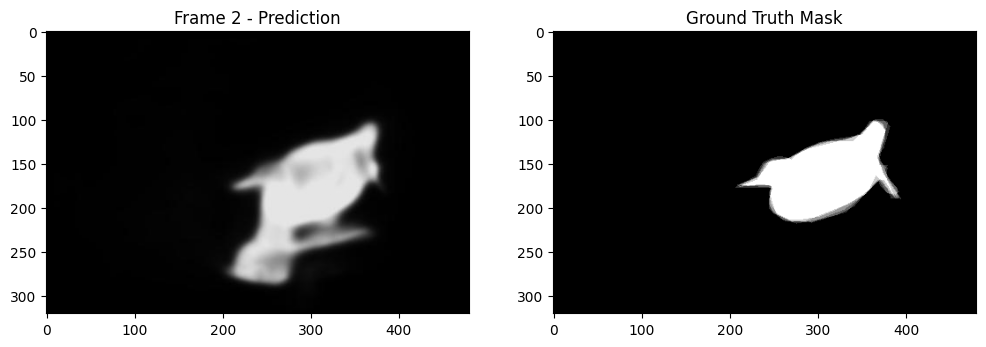

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import time

for i, (preds, mask, fn) in enumerate(ftest_loader):    
    # Remove the batch dimension since it's 1
    preds = preds.squeeze(0)  # Shape: [7, 3, H, W]
    mask = mask.squeeze(0)    # Shape: [1, H, W]
    
    for j in range(preds.shape[0]):  # Loop through the 7 frames
        try:
            # Get j-th prediction and transpose to [H, W, 3] for matplotlib
            pred = preds[j].permute(1, 2, 0).cpu().numpy()
            
            plt.figure(figsize=(12, 6))
            
            # Show prediction
            plt.subplot(1, 2, 1)
            plt.imshow(pred)
            plt.title(f"Frame {j+1} - Prediction")
            
            # Show mask
            plt.subplot(1, 2, 2)
            plt.imshow(mask[0].cpu().numpy(), cmap='gray')
            plt.title("Ground Truth Mask")
            
            # Show filename if available
            if fn and len(fn) > 0:
                print(f"Filename: {fn[0] if isinstance(fn, (list, tuple)) else fn}")
            
            plt.tight_layout()
            plt.show()
            # time.sleep(0.07)
            clear_output(wait=True)
            
        except Exception as e:
            print(f"Error processing frame {j}: {str(e)}")
            break

## Fusing N channel predictions with pixelwise mean

In [16]:
from fusion.means import MeanTypes
import matplotlib.pyplot as plt

fuser = PixelwiseMeanFusion("arithmeticMeanPixelwise", mean_type=MeanTypes.ARITHMETIC)

for i, (preds, mask, filename) in enumerate(ftrain_loader):
    # Fuse the predictions (assuming preds has shape [batch_size, num_models, C, H, W])
    fused_mask = fuser.forward(preds)  # This should return [batch_size, C, H, W]
    
    # Convert tensors to numpy for visualization
    fused_np = fused_mask[0].permute(1, 2, 0).cpu().numpy()  # Convert to [H, W, C] for matplotlib
    gt_mask_np = mask[0][0].cpu().numpy()  # Remove channel dimension for grayscale
    
    plt.figure(figsize=(12, 6))
    
    # Show fused prediction
    plt.subplot(1, 2, 1)
    plt.imshow(fused_np)
    plt.title(f"Fused Prediction - {fuser.name}")
    
    # Show ground truth mask
    plt.subplot(1, 2, 2)
    plt.imshow(gt_mask_np, cmap='gray')
    plt.title("Ground Truth Mask")
    
    # Show filename if available
    if filename:
        print(f"Filename: {filename[0] if isinstance(filename, (list, tuple)) else filename}")
    
    plt.tight_layout()
    plt.show()
    # time.sleep(0.07)
    clear_output(wait=True)
    




Filename: Pine_Grosbeak_0100_38988.png


KeyboardInterrupt: 